SIMPLE LINEAR REGRESSION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_squared_error

In [5]:
df = pd.read_excel("/content/smart_factory_sensor_dataset_870.xlsx")

print(df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
0             470.49     Standard  Evening      Robotic        79.66   
1             360.09   High-Speed  Morning    Pneumatic       105.15   
2             420.47   High-Speed    Night    Pneumatic        81.68   
3             300.29   High-Speed    Night      Robotic        42.61   
4             400.78          Eco  Morning    Hydraulic       107.98   

   Maintenance_Required  Defective  
0                     0          1  
1                     1          1  
2                     0          0  
3               

In [6]:
print(df.tail())

    Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
865    MC_1865   954      0.373        36     37.07         48.47   
866    MC_1866  2723      0.247       107     68.17         39.73   
867    MC_1867  4362      0.560        40     82.31         60.78   
868    MC_1868  3979      0.969        70     77.92         86.55   
869    MC_1869  1732      0.740        78     69.53         28.14   

     Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
865             462.42     Standard  Evening          CNC        29.08   
866             197.53          Eco    Night    Hydraulic        86.29   
867             217.44   High-Speed  Morning          CNC        85.51   
868             391.92          Eco  Evening    Pneumatic        91.38   
869             202.47     Standard  Morning      Robotic        68.80   

     Maintenance_Required  Defective  
865                     0          0  
866                     0          1  
867                    

In [7]:
X = df[['RPM']]

y = df['Temperature']

In [8]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [9]:
predictions = model.predict(X)

print(predictions[:5])

[ 60.00143872 100.433189    90.99170885  54.53093404  95.87906328]


In [10]:
mse = mean_squared_error(y, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 161.56732114836288


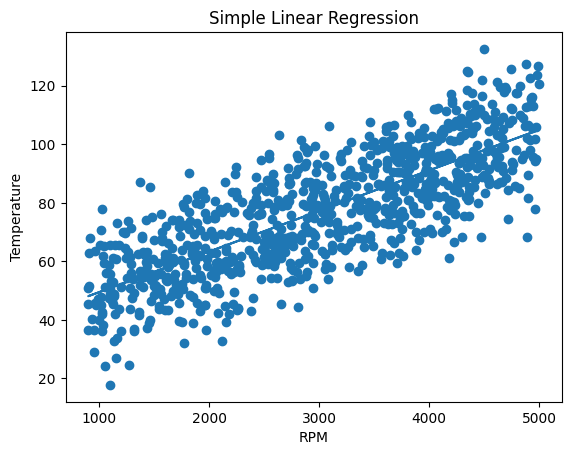

In [11]:
plt.scatter(X, y)

plt.plot(X, predictions)

plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("Simple Linear Regression")

plt.show()

MULTIVARIABLE REGRESSION

In [12]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [13]:
df = pd.read_excel("/content/smart_factory_sensor_dataset_870.xlsx")

print(df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
0             470.49     Standard  Evening      Robotic        79.66   
1             360.09   High-Speed  Morning    Pneumatic       105.15   
2             420.47   High-Speed    Night    Pneumatic        81.68   
3             300.29   High-Speed    Night      Robotic        42.61   
4             400.78          Eco  Morning    Hydraulic       107.98   

   Maintenance_Required  Defective  
0                     0          1  
1                     1          1  
2                     0          0  
3               

In [14]:
X = df[['RPM', 'Vibration', 'Pressure']]

y = df['Temperature']

In [16]:
multi_model = LinearRegression()

multi_model.fit(X, y)

LinearRegression()

In [17]:
multi_predictions = multi_model.predict(X)

print(multi_predictions[:5])

[ 73.98531732  98.6753338   81.34381334  38.68047643 103.25398032]


In [18]:
multi_mse = mean_squared_error(y, multi_predictions)

print("Multivariable Regression MSE:", multi_mse)

Multivariable Regression MSE: 25.018287055966148


SAVE MODEL

In [19]:
import pandas as pd
import joblib

from sklearn.linear_model import LinearRegression

In [20]:
df = pd.read_excel("/content/smart_factory_sensor_dataset_870.xlsx")

print(df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
0             470.49     Standard  Evening      Robotic        79.66   
1             360.09   High-Speed  Morning    Pneumatic       105.15   
2             420.47   High-Speed    Night    Pneumatic        81.68   
3             300.29   High-Speed    Night      Robotic        42.61   
4             400.78          Eco  Morning    Hydraulic       107.98   

   Maintenance_Required  Defective  
0                     0          1  
1                     1          1  
2                     0          0  
3               

In [21]:
X = df[['RPM', 'Vibration', 'Pressure']]

y = df['Temperature']

In [22]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [23]:
joblib.dump(model, "temperature_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
import joblib
import numpy as np

loaded_model = joblib.load(
    "temperature_prediction_model.pkl"
)

new_machine_data = np.array([
    [3500, 0.65, 70]
])

prediction = loaded_model.predict(
    new_machine_data
)

print(
    "Predicted Temperature:",
    prediction[0]
)

Predicted Temperature: 84.63967868014365


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ONE-HOT ENCODING

In [25]:
import pandas as pd

In [26]:
df = pd.read_excel("/content/smart_factory_sensor_dataset_870.xlsx")

print(df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
0             470.49     Standard  Evening      Robotic        79.66   
1             360.09   High-Speed  Morning    Pneumatic       105.15   
2             420.47   High-Speed    Night    Pneumatic        81.68   
3             300.29   High-Speed    Night      Robotic        42.61   
4             400.78          Eco  Morning    Hydraulic       107.98   

   Maintenance_Required  Defective  
0                     0          1  
1                     1          1  
2                     0          0  
3               

In [27]:
print(df['Machine_Mode'].unique())

['Standard' 'High-Speed' 'Eco']


In [28]:
encoded_df = pd.get_dummies(
    df,
    columns=['Machine_Mode'],
    drop_first=True
)

print(encoded_df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption    Shift Machine_Type  Temperature  Maintenance_Required  \
0             470.49  Evening      Robotic        79.66                     0   
1             360.09  Morning    Pneumatic       105.15                     1   
2             420.47    Night    Pneumatic        81.68                     0   
3             300.29    Night      Robotic        42.61                     0   
4             400.78  Morning    Hydraulic       107.98                     1   

   Defective  Machine_Mode_High-Speed  Machine_Mode_Standard  
0          1                    False          

TRAIN TEST SPLIT

In [29]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [30]:
df = pd.read_excel("/content/smart_factory_sensor_dataset_870.xlsx")

print(df.head())

  Machine_ID   RPM  Vibration  Pressure  Humidity  Coolant_Flow  \
0    MC_1000  1760      0.707       106     57.98         19.94   
1    MC_1001  4672      0.379        77     81.82         36.03   
2    MC_1002  3992      0.316        58     57.08         37.88   
3    MC_1003  1366      0.656        24     70.65         32.50   
4    MC_1004  4344      0.755        84     89.53         56.35   

   Power_Consumption Machine_Mode    Shift Machine_Type  Temperature  \
0             470.49     Standard  Evening      Robotic        79.66   
1             360.09   High-Speed  Morning    Pneumatic       105.15   
2             420.47   High-Speed    Night    Pneumatic        81.68   
3             300.29   High-Speed    Night      Robotic        42.61   
4             400.78          Eco  Morning    Hydraulic       107.98   

   Maintenance_Required  Defective  
0                     0          1  
1                     1          1  
2                     0          0  
3               

In [36]:
encoded_df = pd.get_dummies(
    df,
    columns=[
        'Machine_Mode',
        'Shift',
        'Machine_Type'
    ],
    drop_first=True
)

In [37]:
X = encoded_df.drop(
    ['Temperature', 'Defective', 'Machine_ID'],
    axis=1
)

y = encoded_df['Temperature']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [40]:
predictions = model.predict(X_test)

print(predictions[:5])

[84.47715282 48.06767673 96.41144674 98.2141322  71.16263348]


In [41]:
mse = mean_squared_error(
    y_test,
    predictions
)

print("Test MSE:", mse)

Test MSE: 18.34883127838184


In [42]:
print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (696, 14)
Testing Data Size: (174, 14)


LOGISTIC REGRESSION

In [43]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

In [45]:
df = pd.read_excel("smart_factory_sensor_dataset_870.xlsx")

In [46]:
encoded_df = pd.get_dummies(
    df,
    columns=[
        'Machine_Mode',
        'Shift',
        'Machine_Type'
    ],
    drop_first=True
)

In [47]:
X = encoded_df.drop(
    ['Temperature', 'Defective', 'Machine_ID'],
    axis=1
)

y = encoded_df['Defective']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
classifier = LogisticRegression(
    max_iter=1000
)

classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [50]:
predictions = classifier.predict(X_test)

print(predictions[:10])

[1 0 1 1 1 0 1 1 1 0]


In [51]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8563218390804598


In [52]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[70 13]
 [12 79]]
